# Homework part I

The first problem set contains basic tasks in PyTorch.

__Note:__ Instead of doing this part of homework, you can prove your skills otherwise:
* A commit to PyTorch or PyTorch-based repos will do;
* Fully implemented seminar assignment in tensorflow or theano will do;
* Your own project in PyTorch that is developed to a state in which a normal human can understand and appreciate what it does.

In [1]:
# Interactive plots do not work w/o ipympl for some reason...
!pip install -U ipympl -q
from IPython import get_ipython
get_ipython().kernel.do_shutdown(restart=True) # the kernel will be restarted!!!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.1 MB/s eta 0:00:00


{'status': 'ok', 'restart': True}

In [1]:
# Allow interactive plots
from google.colab import output
output.enable_custom_widget_manager()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn
import torch.nn.functional as F
print(torch.__version__)

2.8.0+cu126


### Task I - tensormancy

![img](https://media.giphy.com/media/3o751UMCYtSrRAFRFC/giphy.gif)

When dealing with more complex stuff like neural network, it's best if you use tensors the way samurai uses his sword.


__1.1 The Cannabola__
[(_disclaimer_)](https://gist.githubusercontent.com/justheuristic/e2c1fa28ca02670cabc42cacf3902796/raw/fd3d935cef63a01b85ed2790b5c11c370245cbd7/stddisclaimer.h)

Let's write another function, this time in polar coordinates:
$$\rho(\theta) = (1 + 0.9 \cdot cos (8 \cdot \theta) ) \cdot (1 + 0.1 \cdot cos(24 \cdot \theta)) \cdot (0.9 + 0.05 \cdot cos(200 \cdot \theta)) \cdot (1 + sin(\theta))$$


Then convert it into cartesian coordinates ([howto](http://www.mathsisfun.com/polar-cartesian-coordinates.html)) and plot the results.

Use torch tensors only: no lists, loops, numpy arrays, etc.

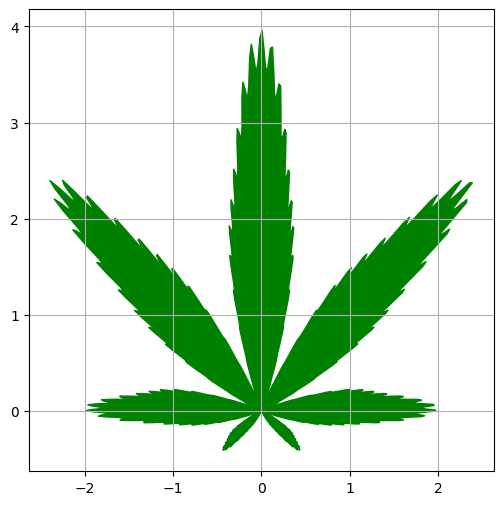

In [3]:
theta = torch.linspace(-np.pi, np.pi, steps=1000)

# compute rho(theta) as per formula above
rho = (1.0 + 0.9 * torch.cos(8.0 * theta)) * (1.0 + 0.1 * torch.cos(24.0 * theta)) * (0.9 + 0.05 * torch.cos(200.0 * theta)) * (1.0 + torch.sin(theta))

# Now convert polar (rho, theta) pairs into cartesian (x,y) to plot them.
x = rho * torch.cos(theta)
y = rho * torch.sin(theta)


plt.figure(figsize=[6, 6])
plt.fill(x.numpy(), y.numpy(), color='green')
plt.grid()

### Task II: The Game of Life

Now it's time for you to make something more challenging. We'll implement Conway's [Game of Life](http://web.stanford.edu/~cdebs/GameOfLife/) in _pure PyTorch_.

While this is still a toy task, implementing game of life this way has one cool benefit: __you'll be able to run it on GPU!__ Indeed, what could be a better use of your GPU than simulating Game of Life on 1M/1M grids?

![img](https://upload.wikimedia.org/wikipedia/commons/e/e5/Gospers_glider_gun.gif)

If you've skipped the URL above out of sloth, here's the Game of Life:
* You have a 2D grid of cells, where each cell is "alive"(1) or "dead"(0)
* Any living cell that has 2 or 3 neighbors survives, else it dies [0,1 or 4+ neighbors]
* Any cell with exactly 3 neighbors becomes alive (if it was dead)

For this task, you are given a reference NumPy implementation that you must convert to PyTorch.
_[NumPy code inspired by: https://github.com/rougier/numpy-100 ]_


__Note:__ You can find convolution in `torch.nn.functional.conv2d(Z,filters)`. Note that it has a different input format.

__Note 2:__ From the mathematical standpoint, PyTorch convolution is actually cross-correlation. Those two are very similar operations. More info: [video tutorial](https://www.youtube.com/watch?v=C3EEy8adxvc), [scipy functions review](http://programmerz.ru/questions/26903/2d-convolution-in-python-similar-to-matlabs-conv2-question), [stack overflow source](https://stackoverflow.com/questions/31139977/comparing-matlabs-conv2-with-scipys-convolve2d).

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
from scipy.signal import correlate2d

def np_update(Z):
    # Count neighbours with convolution
    filters = np.array([[1, 1, 1],
                        [1, 0, 1],
                        [1, 1, 1]])

    N = correlate2d(Z, filters, mode='same')

    # Apply rules
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive
    return Z

In [6]:
def torch_update(Z):
    """
    Implement an update function that does to Z exactly the same as np_update.
    :param Z: torch.FloatTensor of shape [height,width] containing 0s(dead) an 1s(alive)
    :returns: torch.FloatTensor Z after updates.

    You can opt to create new tensor or change Z inplace.
    """

    filters = torch.tensor([[1, 1, 1],
                            [1, 0, 1],
                            [1, 1, 1]], dtype=torch.float32, device=device)

    N = torch.nn.functional.conv2d(Z.reshape(1, 1, Z.shape[0], Z.shape[1]), filters.reshape(1, 1, filters.shape[0], filters.shape[1]), stride=1, padding=1)

    # Apply rules
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive

    return Z


In [7]:
# initial frame
Z_numpy = np.random.choice([0, 1], p=(0.5, 0.5), size=(100, 100))
Z = torch.from_numpy(Z_numpy).type(torch.FloatTensor).to(device)

# your debug polygon :)
Z_new = torch_update(Z.clone())

# tests
Z_reference = np_update(Z_numpy.copy())
assert np.all(Z_new.cpu().numpy() == Z_reference), \
    "your PyTorch implementation doesn't match np_update. Look into Z and np_update(ZZ) to investigate."
print("Well done!")

Well done!


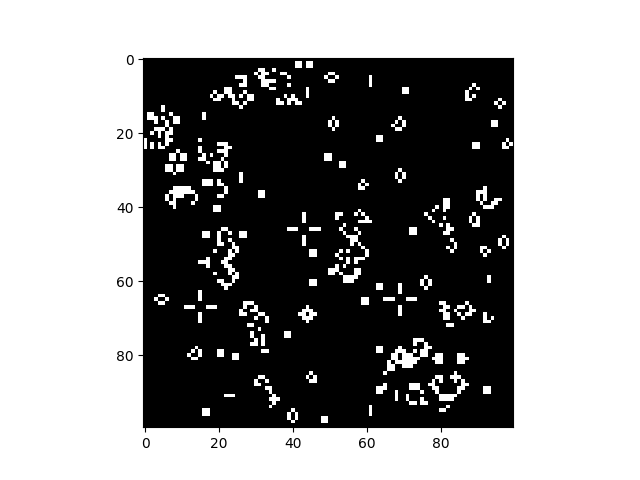

In [9]:
%matplotlib ipympl
plt.ion()

# initialize game field
Z = np.random.choice([0, 1], size=(100, 100))
Z = torch.from_numpy(Z).type(torch.FloatTensor).to(device)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.canvas.draw()

for _ in range(100):
    # update
    Z = torch_update(Z)

    # re-draw image
    ax.clear()
    ax.imshow(Z.cpu().numpy(), cmap='gray')
    fig.canvas.draw()

plt.show()

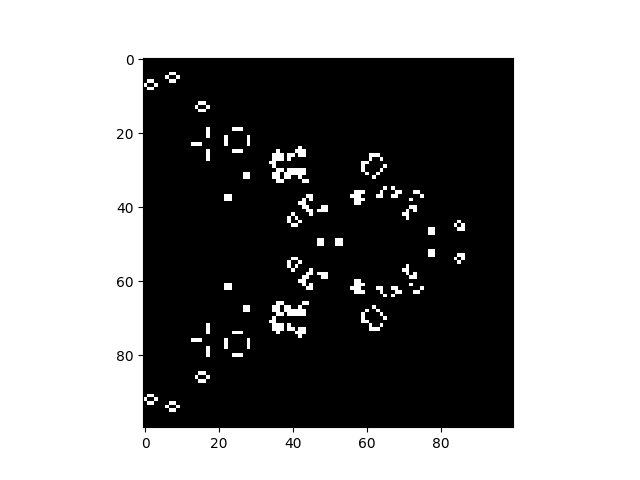

In [11]:
# Some fun setups for your amusement

# parallel stripes
Z = np.arange(100) % 2 + np.zeros([100, 100])
# with a small imperfection
Z[48:52, 50] = 1

Z = torch.from_numpy(Z).type(torch.FloatTensor).to(device)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.canvas.draw()

for _ in range(100):
    Z = torch_update(Z)
    ax.clear()
    ax.imshow(Z.cpu().numpy(), cmap='gray')
    fig.canvas.draw()

plt.show()

More fun with Game of Life: [video](https://www.youtube.com/watch?v=C2vgICfQawE) and/or [Jupyter Notebook](https://nbviewer.jupyter.org/url/norvig.com/ipython/Life.ipynb)

### Task III: Going deeper
<img src="https://www.meme-arsenal.com/memes/00ad90d844e491aaeb6892515c716710.jpg" width=360>

Your third trial is to build your first neural network [almost] from scratch and pure PyTorch.

This time you will solve yet another digit recognition problem, but at a greater scale

* 10 different letters
* 20k samples

We want you to build a network that reaches at least 80% accuracy and has at least 2 linear layers in it. Naturally, it should be nonlinear to beat logistic regression.


With 10 classes you will need to use __Softmax__ at the top instead of sigmoid and train using __categorical crossentropy__ .  Write your own loss or use `torch.nn.functional.nll_loss`. Just make sure you understand what it accepts as input.

Note that you are not required to build 152-layer monsters here. A 2-layer (one hidden, one output) neural network should already give you an edge over logistic regression.


__[bonus kudos]__
If you've already beaten logistic regression with a two-layer net, but enthusiasm still ain't gone, you can try improving the test accuracy even further! It should be possible to reach 90% without convnets.

__SPOILERS!__
At the end of the notebook you will find a few tips and frequent errors.
If you feel confident enough, just start coding right away and get there ~~if~~ once you need to untangle yourself.

In [12]:
!wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall21/week02_autodiff/notmnist.py

In [13]:
from notmnist import load_notmnist
X_train, y_train, X_test, y_test = load_notmnist(letters='ABCDEFGHIJ')
X_train, X_test = X_train.reshape([-1, 784]), X_test.reshape([-1, 784])

Extracting ...
Parsing...
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done


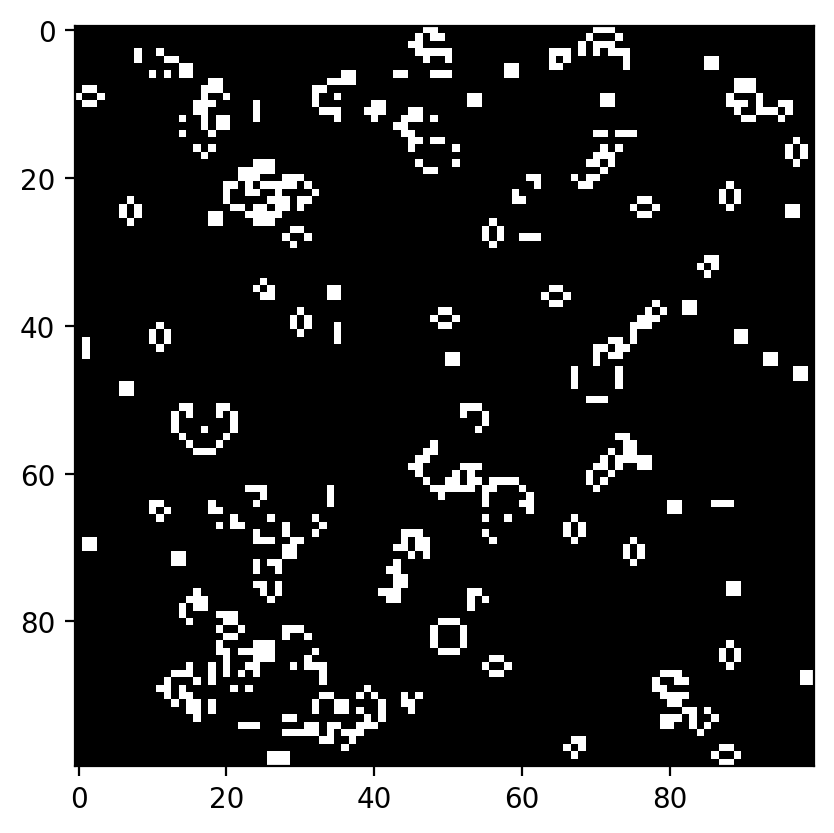

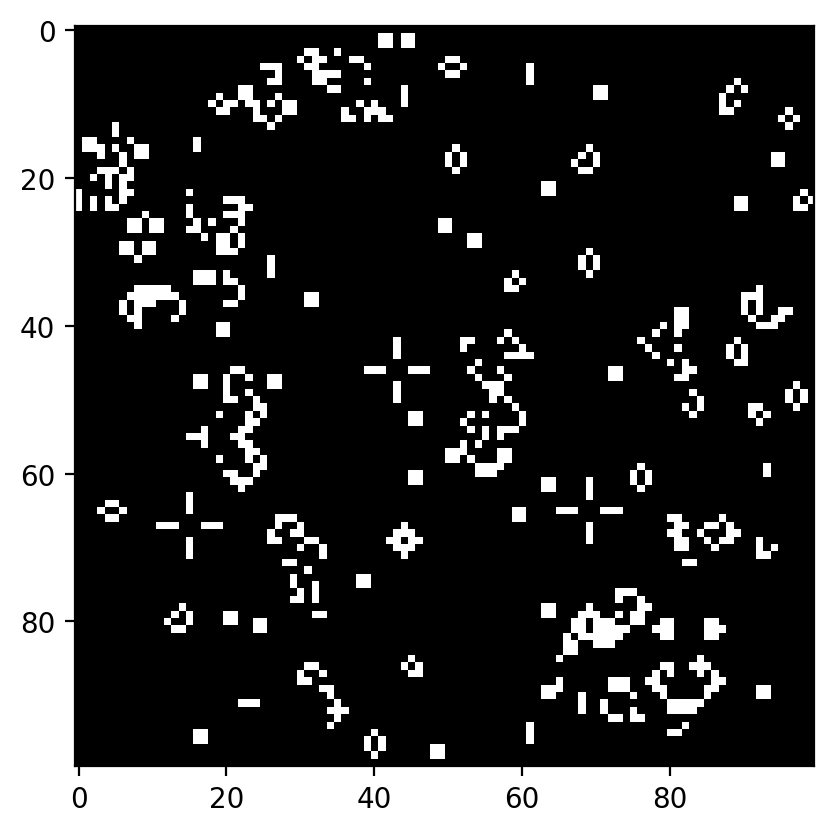

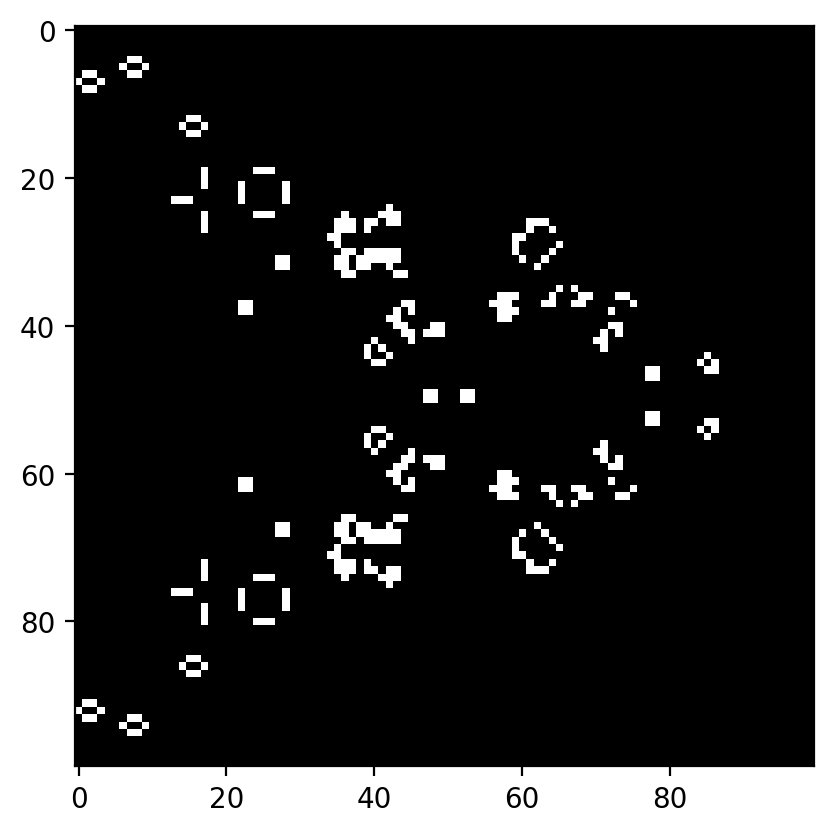

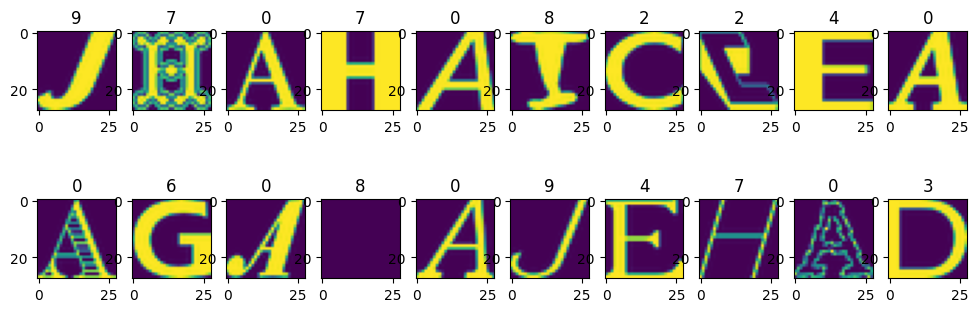

In [14]:
%matplotlib inline
plt.close()
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_train[i].reshape([28, 28]))
    plt.title(str(y_train[i]))

In [16]:
import torch


def _erf_derivative(x: torch.Tensor) -> torch.Tensor:
    """Derivative of the error function erf(x)."""
    coeff = 2.0 / torch.sqrt(torch.tensor(torch.pi))
    return coeff * torch.exp(-(x ** 2))


class CustomGELU(torch.nn.Module):
    """
    Custom implementation of the GELU activation function.

    Args:
        use_approx: whether to use the approximation formula.
    """

    def __init__(self, use_approx: bool = True):
        super().__init__()
        self.use_approx = use_approx

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sqrt2 = 2.0 ** 0.5
        if self.use_approx:
            return x * torch.sigmoid(1.702 * x)
        else:
            return 0.5 * x * (1.0 + torch.erf(x / sqrt2))

    @staticmethod
    def grad(x: torch.Tensor) -> torch.Tensor:
        """Gradient of the exact GELU function."""
        sqrt2 = 2.0 ** 0.5
        return 0.5 * (
            1.0
            + torch.erf(x / sqrt2)
            + x * _erf_derivative(x / sqrt2) / sqrt2
        )

    def backward(self, x: torch.Tensor, grad_out: torch.Tensor) -> torch.Tensor:
        """
        Compute gradient of the loss w.r.t. the GELU input.
        """
        if self.use_approx:
            sig = torch.sigmoid(1.702 * x)
            return grad_out * (sig + 1.702 * x * sig * (1 - sig))
        else:
            return grad_out * CustomGELU.grad(x)


class CustomLinear(torch.nn.Module):
    """
    Custom implementation of a linear (fully-connected) layer.

    Args:
        in_features: number of input features.
        out_features: number of output features.
        bias: whether to use bias.
        device: device where the parameters are stored.
        weight_init: predefined weights.
        bias_init: predefined biases.
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = True,
        device: str = None,
        weight_init: torch.Tensor = None,
        bias_init: torch.Tensor = None,
    ):
        super().__init__()
        limit = 1.0 / torch.sqrt(torch.tensor(in_features, dtype=torch.float32, device=device))

        if weight_init is None:
            self.weight = torch.nn.Parameter(
                torch.empty(in_features, out_features, device=device).uniform_(-limit, limit)
            )
        else:
            self.weight = weight_init

        if bias:
            if bias_init is None:
                self.bias = torch.nn.Parameter(
                    torch.empty(out_features, device=device).uniform_(-limit, limit)
                )
            else:
                self.bias = bias_init
        else:
            self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.bias is not None:
            return x @ self.weight + self.bias
        return x @ self.weight


class CustomLogSoftmax(torch.nn.Module):
    """
    Custom implementation of LogSoftmax.

    Args:
        dim: dimension along which softmax is computed.
    """

    def __init__(self, dim: int = 1):
        super().__init__()
        self.dim = dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shifted = x - torch.max(x, dim=self.dim, keepdim=True).values
        exp_vals = torch.exp(shifted)
        return shifted - torch.log(torch.sum(exp_vals, dim=self.dim, keepdim=True))


In [40]:
import pathlib
import numpy as np
import torch


def train_model(
    X_train,
    y_train,
    model,
    optimizer,
    epochs: int = 100,
    batch_size: int = 256,
    patience: int = 7,
    device: str = "cpu",
):
    """
    Train a model with early stopping based on best loss.

    Args:
        X_train: training input data (numpy array).
        y_train: training target labels (numpy array).
        model: PyTorch model.
        optimizer: PyTorch optimizer.
        epochs: number of epochs to train.
        batch_size: minibatch size.
        patience: stop training if no improvement for N steps.
        device: device for training ("cpu" or "cuda").
    """
    loss_history = []
    best_loss = float("inf")
    best_step = 0

    save_path = pathlib.Path("models/best_model.pt2")
    save_path.parent.mkdir(exist_ok=True)

    for step in range(epochs):
        idx = np.random.choice(len(X_train), batch_size, replace=False)
        xb = torch.tensor(X_train[idx], dtype=torch.float32, device=device)
        yb = torch.tensor(y_train[idx], dtype=torch.long, device=device)

        preds = model(xb)
        loss = torch.nn.functional.nll_loss(preds, yb)

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_step = step
            torch.save(model.state_dict(), save_path)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if step - best_step > patience:
            print(f"[{step}] loss={np.mean(loss_history[-10:]):.3f}")
            print(f"No improvement for {patience} steps → stopping")
            model.load_state_dict(torch.load(save_path))
            model.eval()
            break

        if step % 10 == 0:
            print(f"[{step}] loss={np.mean(loss_history[-10:]):.3f}")

    return loss_history

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# baseline: logistic regression
baseline_model = torch.nn.Sequential(
    CustomLinear(28 * 28, 10, device=device),
    CustomLogSoftmax(dim=0)
).to(device)

optimizer = torch.optim.Adam(baseline_model.parameters())

train_model(
    X_train,
    y_train,
    baseline_model,
    optimizer,
    batch_size=256,
    epochs=100,
    patience=13,
    device=device,
)

with torch.inference_mode():
    logits = baseline_model(torch.tensor(X_test, dtype=torch.float32, device=device))
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy on test set: {accuracy:.6f}")

[0] loss=5.688
[10] loss=4.774
[20] loss=4.246
[30] loss=4.116
[40] loss=4.002
[49] loss=3.976
No improvement for 13 steps → stopping
Accuracy on test set: 0.845759


In [42]:
import torch.nn as nn

network = nn.Sequential(
    CustomLinear(28 * 28, 100, device=device),
    CustomGELU(),
    CustomLinear(100, 10, device=device),
    CustomLogSoftmax(dim=0)
).to(device)

opt = torch.optim.Adam(network.parameters())

train_model(
    X_train,
    y_train,
    network,
    opt,
    batch_size=256,
    epochs=1000,
    patience=13,
    device=device
)

with torch.no_grad():
    logits = network(torch.tensor(X_test, dtype=torch.float32, device=device))
    y_pred_test = torch.argmax(logits, dim=1).cpu().numpy()

accuracy = np.mean(y_pred_test == y_test)
print("Test accuracy: %.6f" % accuracy)

[0] loss=5.525
[10] loss=4.582
[20] loss=4.071
[30] loss=3.887
[40] loss=3.816
[50] loss=3.787
[60] loss=3.774
[67] loss=3.745
No improvement for 13 steps → stopping
Test accuracy: 0.882931
